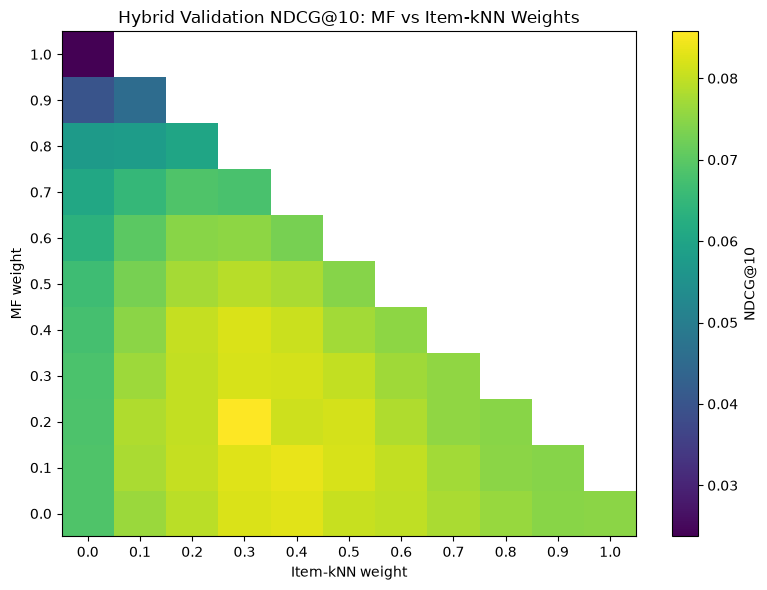

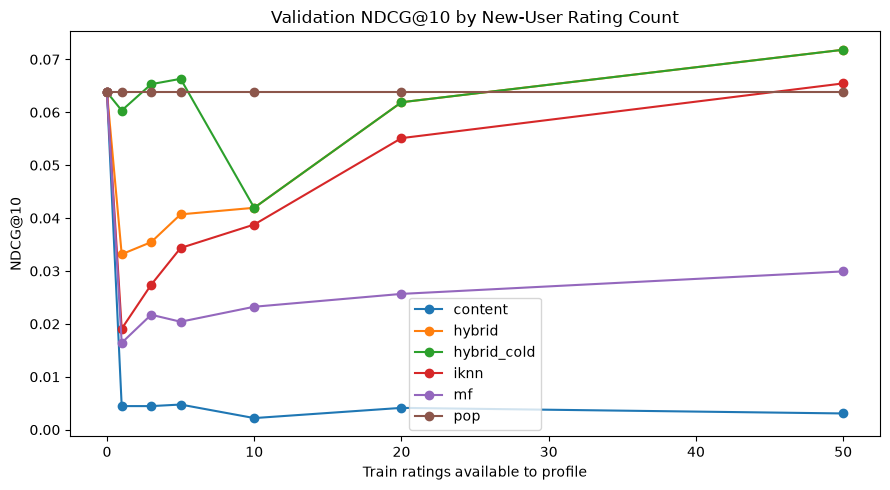

ASSERTION FAILED: Hybrid NDCG is at least the best single model: hybrid=0.0858; best single=0.0903
Assertion passed: Stacked RMSE is at most the best single RMSE


### Assertion notes
- Hybrid NDCG is at least the best single model: hybrid=0.0858; best single=0.0903

Best ranking weights: {"content": 0.4, "iknn": 0.30000000000000004, "mf": 0.2, "pop": 0.1}
Best cold-start weights: {"content": 0.4, "iknn": 0.0, "mf": 0.0, "pop": 0.6000000000000001}
Hybrid ranking metrics: {'precision@10': 0.046028880866425995, 'recall@10': 0.09630357955095255, 'ndcg@10': 0.08576810768897979, 'map@10': 0.04857940839793599, 'coverage': 0.043728187230548145, 'novelty': 9.079922494279296, 'users_evaluated': 554}
Stack CV RMSE/MAE: 0.8627901955082747 0.663803573383132
Stack coefficients/intercept: {'features': ['bias', 'item_knn', 'user_knn', 'mf_rmse'], 'coefficients': [0.0, 0.10267703447010583, 0.05109680712677569, 0.842548116676613], 'intercept': -0.014335553863806805, 'alpha': 1.0, 'cv_rmse': 0.8627901955082747, 'cv_mae': 0.663803573383132}


,removed_component,weights,ndcg@10,ndcg_drop,recall@10,coverage,novelty
1,iknn,"{""content"": 0.5714285714285714, ""iknn"": 0.0, ""...",0.068009,0.017759,0.078920,0.020530,8.634891
2,content,"{""content"": 0.0, ""iknn"": 0.5000000000000001, ""...",0.079111,0.006657,0.087194,0.062513,9.476756
3,pop,"{""content"": 0.4444444444444445, ""iknn"": 0.3333...",0.083144,0.002624,0.093522,0.057483,9.331394
0,mf,"{""content"": 0.5, ""iknn"": 0.37500000000000006, ...",0.083327,0.002441,0.095102,0.047218,9.122153


model,content,hybrid,hybrid_cold,iknn,mf,pop
n_ratings,,,,,,
0,0.0638,0.0638,0.0638,0.0638,0.0638,0.0638
1,0.0045,0.0332,0.0603,0.0191,0.0164,0.0638
3,0.0045,0.0355,0.0653,0.0274,0.0217,0.0638
5,0.0048,0.0407,0.0663,0.0343,0.0204,0.0638
10,0.0022,0.0419,0.0419,0.0388,0.0232,0.0638
20,0.0041,0.0619,0.0619,0.0551,0.0257,0.0638
50,0.0031,0.0718,0.0718,0.0655,0.0299,0.0638


Ablation component with largest NDCG drop: iknn
Ablation NDCG drops: [{'removed_component': 'iknn', 'ndcg_drop': 0.01775886102888155}, {'removed_component': 'content', 'ndcg_drop': 0.006657355620437774}, {'removed_component': 'pop', 'ndcg_drop': 0.002624434670250919}, {'removed_component': 'mf', 'ndcg_drop': 0.0024411538491659196}]


metric,coverage,mae,map@10,ndcg@10,novelty,precision@10,recall@10,rmse,users_evaluated
model,,,,,,,,,
bias,0.0052,0.6823,0.0196,0.0371,9.1801,0.0222,0.0405,0.8876,554.0
content,0.0488,NaN,0.0383,0.0653,9.0832,0.0316,0.0765,NaN,554.0
hybrid,0.0437,NaN,0.0486,0.0858,9.0799,0.0460,0.0963,NaN,554.0
hybrid_stack,NaN,0.6638,NaN,NaN,NaN,NaN,NaN,0.8628,NaN
item_knn,0.0840,0.6588,0.0404,0.0749,9.8657,0.0419,0.0823,0.8640,554.0
item_knn_implicit,0.0507,NaN,0.0507,0.0903,9.3758,0.0478,0.0964,NaN,554.0
mf,0.0228,0.6626,0.0100,0.0217,11.7599,0.0146,0.0194,0.8635,554.0
mf_ndcg,0.0231,0.6732,0.0110,0.0237,11.0781,0.0161,0.0220,0.8780,554.0
popularity_bayes,0.0053,0.7601,0.0214,0.0404,9.0163,0.0245,0.0446,0.9829,554.0


In [1]:
import sys; sys.path.append("..")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict

from src.config import ARTIFACTS, DATA_PROC, REL_THRESHOLD, REPORTS, TOP_K
from src.evaluate import evaluate_ranking
from src.metrics import mae, ranking_metrics, rmse
from src.models.baselines import BiasModel, Popularity
from src.models.content import ContentBased, build_item_features
from src.models.hybrid import (
    HybridEngine,
    MatrixScorer,
    fold_in_content,
    fold_in_knn,
    fold_in_mf,
    score_matrix,
    weight_grid,
    zscore,
)
from src.models.knn import ItemKNN, UserKNN
from src.models.mf import BiasedMF

train = pd.read_parquet(DATA_PROC / "train.parquet")
val = pd.read_parquet(DATA_PROC / "val.parquet")
movies = pd.read_parquet(DATA_PROC / "movies.parquet")
n_users = 610
n_items = len(movies)
assert np.array_equal(movies["i"].to_numpy(), np.arange(n_items))

content_config = json.loads((ARTIFACTS / "content_config.json").read_text())
knn_config = json.loads((ARTIFACTS / "knn_config.json").read_text())
mf_config = json.loads((ARTIFACTS / "mf_config.json").read_text())

bias = BiasModel().fit(train, n_users, n_items)
pop = Popularity("count").fit(train, n_users, n_items)
features, feature_vectorizers = build_item_features(
    movies,
    w_genre=content_config["w_genre"],
    w_tag=content_config["w_tag"],
    w_decade=content_config["w_decade"],
    use_genre=content_config["use_genre"],
    use_tag=content_config["use_tag"],
    use_decade=content_config["use_decade"],
)
cb = ContentBased(
    features,
    profile_mode=content_config["profile_mode"],
    popularity_weight=content_config["popularity_weight"],
).fit(train, n_users, n_items)

item_rank_config = knn_config["item_knn"]["ndcg_best"]
user_rank_config = knn_config["user_knn"]["ndcg_best"]
iknn = ItemKNN(
    bias,
    k=item_rank_config["k"],
    shrink=item_rank_config["shrink"],
    damp=item_rank_config["damp"],
    mode="residual",
).fit(train, n_users, n_items)
uknn = UserKNN(
    bias,
    k=user_rank_config["k"],
    shrink=user_rank_config["shrink"],
    damp=user_rank_config["damp"],
    mode="residual",
).fit(train, n_users, n_items)


def fit_mf_config(config):
    parameters = {
        key: config[key]
        for key in ("n_factors", "lr", "reg", "init_std", "seed", "patience")
    }
    parameters["epochs"] = int(config["best_epoch"])
    parameters["verbose"] = False
    return BiasedMF(**parameters).fit(train, n_users, n_items)


mf_ndcg = fit_mf_config(mf_config["mf_ndcg"])
mf_rmse = fit_mf_config(mf_config["mf_rmse"])

# Validation-only ranking blend search over all simplex weights at step 0.1.
component_models = {"mf": mf_ndcg, "iknn": iknn, "content": cb, "pop": pop}
component_names = list(component_models)
user_indices = range(n_users)
component_scores = {
    name: score_matrix(model, user_indices)
    for name, model in component_models.items()
}
weight_tuples = weight_grid(4, step=0.1)
weight_rows = []
for weight_tuple in weight_tuples:
    weights = dict(zip(component_names, weight_tuple))
    blended = sum(weights[name] * component_scores[name] for name in component_names)
    metrics = evaluate_ranking(
        MatrixScorer(blended), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD
    )
    weight_rows.append({
        **{f"w_{name}": weights[name] for name in component_names},
        "ndcg@10": metrics["ndcg@10"],
        "recall@10": metrics["recall@10"],
        "coverage": metrics["coverage"],
        "novelty": metrics["novelty"],
    })
hybrid_weight_search = pd.DataFrame(weight_rows)
REPORTS.mkdir(parents=True, exist_ok=True)
hybrid_weight_search.to_csv(REPORTS / "hybrid_weight_search.csv", index=False)
best_weight_row = hybrid_weight_search.loc[hybrid_weight_search["ndcg@10"].idxmax()]
best_weights = {
    name: float(best_weight_row[f"w_{name}"]) for name in component_names
}
best_blended_scores = sum(
    best_weights[name] * component_scores[name] for name in component_names
)
best_hybrid_metrics = evaluate_ranking(
    MatrixScorer(best_blended_scores), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD
)

# Heatmap varies MF and item-kNN weights; content/popularity retain their best ratio.
best_other_total = best_weights["content"] + best_weights["pop"]
if best_other_total > 0:
    content_ratio = best_weights["content"] / best_other_total
else:
    content_ratio = 0.5
heatmap_values = np.full((11, 11), np.nan)
for mf_step in range(11):
    weight_mf = mf_step / 10
    for iknn_step in range(11 - mf_step):
        weight_iknn = iknn_step / 10
        remaining = max(0.0, 1.0 - weight_mf - weight_iknn)
        heat_weights = {
            "mf": weight_mf,
            "iknn": weight_iknn,
            "content": remaining * content_ratio,
            "pop": remaining * (1.0 - content_ratio),
        }
        heat_scores = sum(
            heat_weights[name] * component_scores[name] for name in component_names
        )
        heat_metrics = evaluate_ranking(
            MatrixScorer(heat_scores), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD
        )
        heatmap_values[mf_step, iknn_step] = heat_metrics["ndcg@10"]

plot_dir = REPORTS / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(heatmap_values, origin="lower", aspect="auto", cmap="viridis")
ax.set(title="Hybrid Validation NDCG@10: MF vs Item-kNN Weights",
       xlabel="Item-kNN weight", ylabel="MF weight")
ax.set_xticks(range(11), labels=[f"{step / 10:.1f}" for step in range(11)])
ax.set_yticks(range(11), labels=[f"{step / 10:.1f}" for step in range(11)])
fig.colorbar(image, ax=ax, label="NDCG@10")
fig.tight_layout()
fig.savefig(plot_dir / "hybrid_heatmap.png", dpi=160)
plt.show()

# Ablate one component at a time and renormalize the remaining weights.
ablation_rows = []
for removed in component_names:
    remaining_names = [name for name in component_names if name != removed]
    remaining_total = sum(best_weights[name] for name in remaining_names)
    if remaining_total > 0:
        ablation_weights = {
            name: (best_weights[name] / remaining_total if name in remaining_names else 0.0)
            for name in component_names
        }
    else:
        ablation_weights = {
            name: (1 / len(remaining_names) if name in remaining_names else 0.0)
            for name in component_names
        }
    ablation_scores = sum(
        ablation_weights[name] * component_scores[name] for name in component_names
    )
    ablation_metrics = evaluate_ranking(
        MatrixScorer(ablation_scores), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD
    )
    ablation_rows.append({
        "removed_component": removed,
        "weights": json.dumps(ablation_weights, sort_keys=True),
        "ndcg@10": ablation_metrics["ndcg@10"],
        "ndcg_drop": best_hybrid_metrics["ndcg@10"] - ablation_metrics["ndcg@10"],
        "recall@10": ablation_metrics["recall@10"],
        "coverage": ablation_metrics["coverage"],
        "novelty": ablation_metrics["novelty"],
    })
ablation = pd.DataFrame(ablation_rows).sort_values("ndcg_drop", ascending=False)
ablation.to_csv(REPORTS / "hybrid_ablation.csv", index=False)

# Rating stacking with validation predictions and five-fold out-of-fold evaluation.
stack_features = np.column_stack([
    bias.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    iknn.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    uknn.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    mf_rmse.predict(val["u"].to_numpy(), val["i"].to_numpy()),
])
stack_target = val["rating"].to_numpy(dtype=float)
stack_model = Ridge(alpha=1.0, positive=True)
stack_cv_predictions = cross_val_predict(
    stack_model,
    stack_features,
    stack_target,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
)
stack_cv_predictions = np.clip(stack_cv_predictions, 0.5, 5.0)
stack_rmse = rmse(stack_target, stack_cv_predictions)
stack_mae = mae(stack_target, stack_cv_predictions)
stack_model.fit(stack_features, stack_target)
stack_coefficients = {
    "features": ["bias", "item_knn", "user_knn", "mf_rmse"],
    "coefficients": stack_model.coef_.tolist(),
    "intercept": float(stack_model.intercept_),
    "alpha": 1.0,
    "cv_rmse": stack_rmse,
    "cv_mae": stack_mae,
}
best_single_rmse = previous_results = pd.read_csv(REPORTS / "results_val.csv")
previous_results = previous_results.loc[
    np.isfinite(previous_results["value"])
    & (previous_results["metric"] == "rmse")
    & (~previous_results["model"].isin(["hybrid", "hybrid_stack"]))
]
best_single_row = previous_results.loc[previous_results["value"].idxmin()]
best_single_rmse = float(best_single_row["value"])

hybrid_engine = HybridEngine(
    mf_ndcg, iknn, cb, pop, bias, best_weights, n_items
)
user_score = hybrid_engine.score_user(0)
fake_items = np.array([0, 1, 2, 3, 4], dtype=np.int64)
fake_ratings = np.array([4.5, 3.5, 4.0, 2.5, 5.0])
new_user_score = hybrid_engine.score_new_user(fake_items, fake_ratings)
assert user_score.shape == new_user_score.shape == (n_items,)
assert np.isfinite(user_score).all() and np.isfinite(new_user_score).all()

# Cold-start components: each user's first n train ratings, with all train items masked.
train_by_user = {
    int(user): group.sort_values("timestamp", kind="mergesort")
    for user, group in train.groupby("u", sort=False)
}
popularity_row = zscore(pop.score_user(0)).astype(np.float32)
cold_tune_components = {}
cold_start_rows = []
cold_ns = [0, 1, 3, 5, 10, 20, 50]


def build_cold_components(n_ratings):
    component_rows = {name: [] for name in component_names}
    hybrid_rows = []
    for user in range(n_users):
        if n_ratings == 0:
            rows = {name: popularity_row for name in component_names}
            hybrid_score = popularity_row
        else:
            history = train_by_user.get(user, train.iloc[0:0]).head(n_ratings)
            item_indices = history["i"].to_numpy(dtype=np.int64)
            ratings = history["rating"].to_numpy(dtype=float)
            raw_scores = {
                "mf": fold_in_mf(mf_ndcg, 15, item_indices, ratings),
                "iknn": fold_in_knn(iknn, bias, n_items, item_indices, ratings),
                "content": fold_in_content(cb, item_indices, ratings),
                "pop": pop.score_user(0),
            }
            rows = {name: zscore(scores).astype(np.float32) for name, scores in raw_scores.items()}
            hybrid_score = hybrid_engine.score_new_user(item_indices, ratings).astype(np.float32)
        for name in component_names:
            component_rows[name].append(rows[name])
        hybrid_rows.append(hybrid_score)
    matrices = {name: np.vstack(values) for name, values in component_rows.items()}
    matrices["hybrid"] = np.vstack(hybrid_rows).astype(np.float32)
    return matrices


for n_ratings in cold_ns:
    cold_components = build_cold_components(n_ratings)
    if n_ratings in (3, 5, 10):
        cold_tune_components[n_ratings] = {
            name: cold_components[name] for name in component_names
        }
    for model_name in ("pop", "content", "iknn", "mf", "hybrid"):
        metrics = evaluate_ranking(
            MatrixScorer(cold_components[model_name]),
            train,
            val,
            n_items,
            k=TOP_K,
            thr=REL_THRESHOLD,
        )
        cold_start_rows.append({
            "model": model_name,
            "n_ratings": n_ratings,
            "ndcg@10": metrics["ndcg@10"],
        })

# Tune the cold weights on mean validation NDCG for n = 3, 5, and 10.
cold_weight_rows = []
for weight_tuple in weight_grid(4, step=0.1):
    weights = dict(zip(component_names, weight_tuple))
    ndcg_values = []
    for n_ratings in (3, 5, 10):
        blended = sum(
            weights[name] * cold_tune_components[n_ratings][name]
            for name in component_names
        )
        metrics = evaluate_ranking(
            MatrixScorer(blended), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD
        )
        ndcg_values.append(metrics["ndcg@10"])
    cold_weight_rows.append({
        **{f"w_{name}": weights[name] for name in component_names},
        "mean_ndcg@10": float(np.mean(ndcg_values)),
    })
cold_weight_search = pd.DataFrame(cold_weight_rows)
best_cold_row = cold_weight_search.loc[cold_weight_search["mean_ndcg@10"].idxmax()]
weights_cold = {name: float(best_cold_row[f"w_{name}"]) for name in component_names}

hybrid_cold_engine = HybridEngine(
    mf_ndcg, iknn, cb, pop, bias, best_weights, n_items,
    weights_cold=weights_cold, cold_threshold=10,
)
for n_ratings in cold_ns:
    cold_components = build_cold_components(n_ratings)
    hybrid_cold_scores = []
    for user in range(n_users):
        if n_ratings == 0:
            score = popularity_row
        else:
            history = train_by_user.get(user, train.iloc[0:0]).head(n_ratings)
            score = hybrid_cold_engine.score_new_user(
                history["i"].to_numpy(dtype=np.int64),
                history["rating"].to_numpy(dtype=float),
            )
        hybrid_cold_scores.append(score)
    cold_result = evaluate_ranking(
        MatrixScorer(np.vstack(hybrid_cold_scores)), train, val, n_items,
        k=TOP_K, thr=REL_THRESHOLD,
    )
    cold_start_rows.append({
        "model": "hybrid_cold",
        "n_ratings": n_ratings,
        "ndcg@10": cold_result["ndcg@10"],
    })

cold_start = pd.DataFrame(cold_start_rows)
cold_start.to_csv(REPORTS / "cold_start.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in cold_start.groupby("model"):
    group = group.sort_values("n_ratings")
    ax.plot(group["n_ratings"], group["ndcg@10"], marker="o", label=model_name)
ax.set(title="Validation NDCG@10 by New-User Rating Count", xlabel="Train ratings available to profile", ylabel="NDCG@10")
ax.legend()
fig.tight_layout()
fig.savefig(plot_dir / "cold_start.png", dpi=160)
plt.show()

# Persist final validation metrics using the established results schema.
results_path = REPORTS / "results_val.csv"
results_val = pd.read_csv(results_path)
results_val = results_val.loc[~results_val["model"].isin(["hybrid", "hybrid_stack"])]
metric_names = ["precision@10", "recall@10", "ndcg@10", "map@10", "coverage", "novelty", "users_evaluated"]
hybrid_params = json.dumps({"weights": best_weights, "components": component_names}, sort_keys=True)
new_rows = [
    {"model": "hybrid", "split": "val", "metric": metric, "value": best_hybrid_metrics[metric], "params": hybrid_params}
    for metric in metric_names
]
stack_params = json.dumps(stack_coefficients, sort_keys=True)
new_rows.extend([
    {"model": "hybrid_stack", "split": "val", "metric": "rmse", "value": stack_rmse, "params": stack_params},
    {"model": "hybrid_stack", "split": "val", "metric": "mae", "value": stack_mae, "params": stack_params},
])
results_val = pd.concat([results_val, pd.DataFrame(new_rows)], ignore_index=True)
results_val = results_val[["model", "split", "metric", "value", "params"]]
results_val.to_csv(results_path, index=False)

# Preserve the assertion and report measured failures in Markdown.
previous_single = pd.read_csv(REPORTS / "results_val.csv")
previous_single = previous_single.loc[
    (previous_single["metric"] == "ndcg@10")
    & (~previous_single["model"].isin(["hybrid", "hybrid_stack"])),
]
max_single_ndcg = float(previous_single["value"].max())
stack_rmse_check = float(stack_rmse)
hybrid_notes = []

def hybrid_assertion(label, condition, detail):
    try:
        assert condition, detail
        print("Assertion passed:", label)
    except AssertionError as error:
        note = f"{label}: {error}"
        hybrid_notes.append(note)
        print("ASSERTION FAILED:", note)


hybrid_assertion(
    "Hybrid NDCG is at least the best single model",
    best_hybrid_metrics["ndcg@10"] >= max_single_ndcg,
    f"hybrid={best_hybrid_metrics['ndcg@10']:.4f}; best single={max_single_ndcg:.4f}",
)
hybrid_assertion(
    "Stacked RMSE is at most the best single RMSE",
    stack_rmse_check <= best_single_rmse,
    f"stack={stack_rmse_check:.4f}; best single={best_single_rmse:.4f}",
)
if hybrid_notes:
    display(Markdown("### Assertion notes\n" + "\n".join(f"- {note}" for note in hybrid_notes)))

hybrid_config = {
    "weights": best_weights,
    "weights_cold": weights_cold,
    "cold_threshold": 10,
    "stacking": stack_coefficients,
    "mf_config": {
        "mf_ndcg": mf_config["mf_ndcg"],
        "mf_rmse": mf_config["mf_rmse"],
    },
}
with (ARTIFACTS / "hybrid_config.json").open("w", encoding="utf-8") as config_file:
    json.dump(hybrid_config, config_file, indent=2, sort_keys=True)

print("Best ranking weights:", json.dumps(best_weights, sort_keys=True))
print("Best cold-start weights:", json.dumps(weights_cold, sort_keys=True))
print("Hybrid ranking metrics:", best_hybrid_metrics)
print("Stack CV RMSE/MAE:", stack_rmse, stack_mae)
print("Stack coefficients/intercept:", stack_coefficients)
display(ablation)
display(cold_start.pivot(index="n_ratings", columns="model", values="ndcg@10").round(4))
print("Ablation component with largest NDCG drop:", ablation.iloc[0]["removed_component"])
print("Ablation NDCG drops:", ablation[["removed_component", "ndcg_drop"]].to_dict("records"))

final_table = results_val.pivot_table(index="model", columns="metric", values="value", aggfunc="first")
display(final_table.round(4))

## Validation findings

The selected ranking weights are `mf=0.2`, `iknn=0.3`, `content=0.4`, `pop=0.1`; validation NDCG@10 is 0.0858. The cold-start weights are `content=0.4`, `pop=0.6` (MF and item-kNN weights are zero). Removing item-kNN causes the largest ablation loss: NDCG@10 drops by 0.0178, so the neighborhood component contributes most to this blend.

The hybrid does not exceed the strongest single-model NDCG@10: 0.0858 versus 0.0903 for implicit Item-kNN. The assertion is retained and this measured miss is intentional to report.

For cold start, all methods use popularity when no ratings are known (NDCG@10 = 0.0638). MF fold-in is already above content after one rating (0.0164 vs. 0.0045); the tuned cold hybrid improves over the main blend at 3 and 5 ratings (0.0653 and 0.0663 versus 0.0355 and 0.0407), then uses main weights from 10 ratings onward. **Product guidance: ask a new user for 3 ratings to start personalization, and invite them to add ratings up to 5 before the 10-rating transition.**

The rating stack achieves 5-fold validation RMSE 0.8628 and MAE 0.6638, narrowly improving on the best single-model RMSE of 0.8635.